# JN6a · Interrogate the oracle, then write your own APR

*"Did Berkeley actually build what it told the state it built?"* By now you've reconstructed a housing record straight from raw permits (JN1–JN5). This is the notebook where that work earns its keep: you produce a real **HCD-form Annual Progress Report (APR)** of your own, and you get to know the number you'll eventually grade it against — the city's *own* submitted report.

That submitted report is your **oracle** — the answer key. But here's the thing a careful analyst learns the hard way: **an answer key is a hypothesis too.** You don't get to trust it just because the city filed it. So this half does two jobs — first **interrogate the oracle** (locate it, verify it, check that it's even current), then **generate your APR** in HCD's exact shape.

**Curriculum notebook 6a of 6.**

> Clonable + read-only on the source data; it writes one *output* spreadsheet (a rendering of your own numbers — never a change to the city's data).

### Running the cells

To run a cell, click it and press **Shift + Return**, or click the **run (▸) button** on the cell. The simplest way through any notebook here is to start at the top and run each cell in order, reading the output that appears beneath it.

Some of the computational cells may look complex right now — that's expected, and it's fine. **You don't need to understand every line yet;** the ideas become clear as you go. Run them, watch what they produce, and keep moving.

💡 Tip: the **Next** link opens the following notebook in a new tab. If Colab says you have too many sessions, just close the previous tab and continue.

<!-- NAV:auto-generated by scripts/build_nav.py — do not edit by hand -->

← Previous: [JN5 · Year & cycle tagging](https://colab.research.google.com/github/blockXblock/berkeley-housing-analysis/blob/main/notebooks/curriculum/JN5_year_cycle.ipynb)  |  Next: [JN6b · Join, decompose, score](https://colab.research.google.com/github/blockXblock/berkeley-housing-analysis/blob/main/notebooks/curriculum/JN6b_join_score.ipynb) →

## (run first) Colab setup

Fetches the data + shared modules from R2. **No-op if you already have the repo locally** (it detects a checkout and skips). On Colab / a bare session it recreates the minimal repo layout under the working directory so the config cell below finds everything unchanged.

In [1]:
# === COLAB BOOTSTRAP - fetch curriculum data + modules from R2 (NO-OP if the repo is local) ===
from pathlib import Path
import sys, urllib.request, urllib.parse, tarfile, subprocess

R2 = 'https://pub-2cee87f70da64080ab70ee0a34b55099.r2.dev/curriculum'
USE_CLEAN = False   # False: raw .xlsx path (JN1's messy-data lesson).  True (skip-ingest): permits_clean.*

_here = Path.cwd()
_have_repo = (_here/'scripts'/'build_v2').exists() or any((p/'scripts'/'build_v2').exists() for p in _here.parents)

def _get(url):
    # r2.dev sits behind Cloudflare, which 403s the default 'Python-urllib' User-Agent; send a browser UA.
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req, timeout=60) as r:
        return r.read()

if _have_repo:
    print('local repo detected - no fetch needed')
else:
    try:
        import pyarrow  # the parquet / USE_CLEAN path needs it; Colab has pandas, maybe not pyarrow
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pyarrow'], check=True)
    def _fetch(url, dest):
        dest = Path(dest)
        if dest.exists():
            return                                   # cached: re-runs don't re-download
        dest.parent.mkdir(parents=True, exist_ok=True)
        dest.write_bytes(_get(url)); print('fetched', dest.name)
    # 1) shared modules -> ./scripts/...  (the config-cell repo-root walk then finds scripts/build_v2)
    if not (_here/'scripts'/'build_v2').exists():
        Path('modules.tgz').write_bytes(_get(f'{R2}/curriculum_modules.tar.gz'))
        _tar = tarfile.open('modules.tgz')
        try: _tar.extractall(_here, filter='data')      # py3.12+: safe extract, no deprecation warning
        except TypeError: _tar.extractall(_here)         # older python has no filter arg
        _tar.close(); Path('modules.tgz').unlink(missing_ok=True)   # tidy: drop the intermediate tarball
        print('extracted modules -> ./scripts/')
    # 2) data -> the SAME relative paths the notebooks use (raw .xlsx AND clean exports, both fetched)
    for rel in ['data/raw/cpra-downloads/BP_Annual Permit Report-2018-2022.xlsx',
                'data/raw/cpra-downloads/BP_Annual Permit Report-2023-2025.xlsx',
                'databases/hcd_apr_mirror_2026-06-17_fresh.db',
                'databases/hcd_apr_mirror.db',
                'data/processed/permits_clean.csv',
                'data/processed/permits_clean.parquet',
                'data/processed/permits_clean_README.md']:
        _fetch(f"{R2}/data/{urllib.parse.quote(rel.split('/')[-1])}", _here/rel)   # quote -> %20 for the spaced .xlsx names
    print('curriculum bundle ready (fetched from R2)')


local repo detected - no fetch needed


In [2]:
def md(t):
    from IPython.display import Markdown, display
    display(Markdown(t))

## Config

In [3]:
# === CONFIG - point this at YOUR city's data (clonable) ===
from pathlib import Path
import sys, glob
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'scripts' / 'build_v2').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
PERMIT_GLOB = str(REPO_ROOT / 'data/raw/cpra-downloads/BP_Annual Permit Report-*.xlsx')
ORACLE_DB   = str(REPO_ROOT / 'databases/hcd_apr_mirror_2026-06-17_fresh.db')  # the FRESH (deduped) CKAN pull
STALE_DB    = str(REPO_ROOT / 'databases/hcd_apr_mirror.db')                   # an older pull, for the currency lesson
OUTDIR      = REPO_ROOT / 'notebooks/curriculum/output'; OUTDIR.mkdir(parents=True, exist_ok=True)
HEADER_ROW  = 7
sys.path.insert(0, str(REPO_ROOT / 'scripts')); sys.path.insert(0, str(REPO_ROOT / 'scripts' / 'build_v2'))
print('repo root:', REPO_ROOT)

repo root: /Users/johngage/berkeley-data


# PHASE 6a - Interrogate the oracle

The city files an **Annual Progress Report (APR)** with the state (HCD), published on the CKAN open-data portal. That is your **oracle** - the number to score against. But finding it and *trusting* it is a skill: you must locate the right tables, know what is missing, and **verify the oracle to ground truth before believing it.** An oracle is a hypothesis too.

### What's actually in the city's submission — and what isn't?

Before we can grade anything against the oracle, we have to *open* it and see what it contains. The city files its APR with the state (HCD) and it gets published on the CKAN open-data portal; we pulled Berkeley's into a local mirror (for another city you'd pull its submission the same way). The APR is a set of tables — **Table A** (applications) and **Table A2** (the building-activity report: entitlements, building permits, and the **CO/completions** we care about). But just as important as what's *there* is what's *missing*.

**Our plan:** list the tables the mirror actually holds, and check for one we might expect but won't find — cumulative RHNA progress — so we know the limit of what this oracle can answer before we lean on it.

In [4]:
import sqlite3
# open the oracle mirror READ-ONLY (mode=ro) - we interrogate it, never write to it
con = sqlite3.connect(f'file:{ORACLE_DB}?mode=ro', uri=True)
# ask the DB itself which APR tables it holds, instead of assuming
tables = [r[0] for r in con.execute("SELECT name FROM sqlite_master WHERE type='table' AND name LIKE 'table_%'")]
print('oracle tables:', tables)
print('Table B (RHNA progress) present? ', 'table_b' in tables,
      ' <- ABSENT: cumulative RHNA progress is NOT in the mirror -> a coverage/soft lesson for later')

oracle tables: ['table_a2', 'table_a']
Table B (RHNA progress) present?  False  <- ABSENT: cumulative RHNA progress is NOT in the mirror -> a coverage/soft lesson for later


In [5]:
md(f'''## What just happened

We asked the mirror itself what it holds, and it answered: **{len(tables)}** tables — `{"`, `".join(tables)}`. The completions we need live in `table_a2`. We also asked whether a Table B (cumulative RHNA progress) is present, and it is **{'table_b' in tables}** — *absent*. That absence isn't a bug; it's a boundary. It means this oracle can confirm year-by-year completions but **cannot** answer "how far along is Berkeley toward its RHNA goal?" Knowing what your answer key *can't* score is the first step in trusting it.''')

## What just happened

We asked the mirror itself what it holds, and it answered: **2** tables — `table_a2`, `table_a`. The completions we need live in `table_a2`. We also asked whether a Table B (cumulative RHNA progress) is present, and it is **False** — *absent*. That absence isn't a bug; it's a boundary. It means this oracle can confirm year-by-year completions but **cannot** answer "how far along is Berkeley toward its RHNA goal?" Knowing what your answer key *can't* score is the first step in trusting it.

### Trap-lesson: is the oracle even reading right? (units, not rows)

Here's the first place a careless analyst goes wrong: they `SELECT COUNT(*)` from the completions table and report *that* as "homes built." But a single Table A2 row can be one building with **many units** — so a row count badly undercounts. Completions in Table A2 are **units**: the sum of the 11 `CO_*_INCOME` columns. Before we trust a single number this oracle gives us, we reconcile it to something we already know is true.

**Our plan:** Berkeley publicly reported **708 CO units for CY2024** — that's our anchor. We'll sum the 11 income columns per year and check whether the oracle's CY2024 lands exactly on 708. If it does, we're reading the oracle correctly; if it doesn't, we found a bug *before* trusting it.

In [6]:
import sqlite3
CO_COLS = ['CO_ACUTELY_LOW_INCOME_DR','CO_ACUTELY_LOW_INCOME_NDR','CO_EXTREMELY_LOW_INCOME_DR',
           'CO_EXTREMELY_INCOME_NDR','CO_VLOW_INCOME_DR','CO_VLOW_INCOME_NDR','CO_LOW_INCOME_DR',
           'CO_LOW_INCOME_NDR','CO_MOD_INCOME_DR','CO_MOD_INCOME_NDR','CO_ABOVE_MOD_INCOME']
CO_SUM = '+'.join(f"CAST(NULLIF({c},'') AS INT)" for c in CO_COLS)
def oracle_co_units_by_year(db):
    c = sqlite3.connect(f'file:{db}?mode=ro', uri=True)
    return dict((int(y), u or 0) for y, u in
                c.execute(f"SELECT YEAR, SUM({CO_SUM}) FROM table_a2 WHERE CO_ISSUE_DT1 <> '' GROUP BY YEAR"))
fresh = oracle_co_units_by_year(ORACLE_DB)
print('oracle CO UNITS by year (fresh):', dict(sorted(fresh.items())))
print(f'  CY2024 = {fresh[2024]}  (known anchor: 708)  ->', 'RECONCILES' if fresh[2024] == 708 else 'MISMATCH')

oracle CO UNITS by year (fresh): {2018: 229, 2019: 313, 2020: 405, 2021: 331, 2022: 828, 2023: 716, 2024: 708, 2025: 492}
  CY2024 = 708  (known anchor: 708)  -> RECONCILES


In [7]:
md(f'''## What just happened

We summed the 11 income columns per year and the oracle's CY2024 came back as **{fresh[2024]}** units — exactly the **708** anchor Berkeley reported publicly. That single match is doing a lot of work: it tells us we picked the right table, summed the right columns, and read *units* rather than rows. For context, the oracle also reports **{fresh[2023]}** units in 2023 and **{fresh[2025]}** in 2025. The anchor reconciled, so from here we can trust the oracle's shape — *for the years it's actually current*, which is exactly what we check next.''')

## What just happened

We summed the 11 income columns per year and the oracle's CY2024 came back as **708** units — exactly the **708** anchor Berkeley reported publicly. That single match is doing a lot of work: it tells us we picked the right table, summed the right columns, and read *units* rather than rows. For context, the oracle also reports **716** units in 2023 and **492** in 2025. The anchor reconciled, so from here we can trust the oracle's shape — *for the years it's actually current*, which is exactly what we check next.

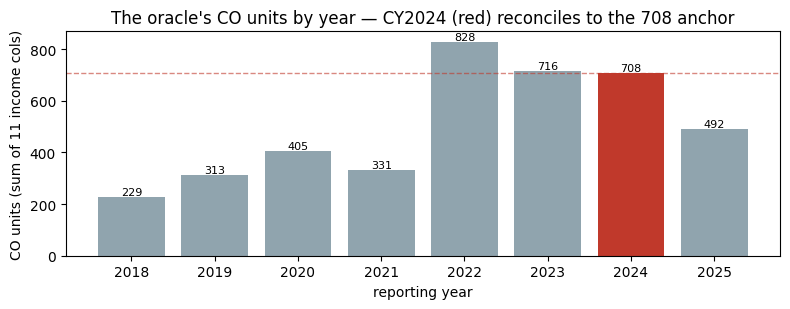

In [8]:
import matplotlib.pyplot as plt
# read the verified oracle units-by-year; the anchor year is highlighted
_yrs = sorted(fresh)
_vals = [fresh[y] for y in _yrs]
_colors = ['#c0392b' if y == 2024 else '#90a4ae' for y in _yrs]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar([str(y) for y in _yrs], _vals, color=_colors)
ax.axhline(fresh[2024], color='#c0392b', ls='--', lw=1, alpha=0.6)
for y, v in zip(_yrs, _vals):
    ax.text(str(y), v + 8, str(v), ha='center', fontsize=8)
ax.set_title("The oracle's CO units by year — CY2024 (red) reconciles to the 708 anchor")
ax.set_xlabel('reporting year'); ax.set_ylabel('CO units (sum of 11 income cols)')
plt.tight_layout(); plt.show()

### Trap-lesson: is the oracle current? — the city's own double-submission

A reconciled oracle can still be the *wrong copy*. Files get re-pulled, re-submitted, and superseded — and an answer key that's correct-but-stale will quietly grade you against last month's reality. Here's a real example: Berkeley accidentally submitted its **CY2025** numbers **twice**, and an older mirror we have on disk still carries the doubled rows. HCD later deduplicated the official copy.

**Our plan:** open the older ("stale") mirror alongside the fresh one and compare CY2025. If currency matters, the stale file should show roughly *double* the fresh deduped count — and we'd only ever catch the city's slip by checking, rather than trusting the first file we happened to find.

In [9]:
stale = oracle_co_units_by_year(STALE_DB)
print(f'CY2025  stale mirror = {stale[2025]}   fresh (deduped) = {fresh[2025]}')
print(f'  the {stale[2025] - fresh[2025]} phantom units = the city double-submission (HCD later deduped it)')

CY2025  stale mirror = 984   fresh (deduped) = 492
  the 492 phantom units = the city double-submission (HCD later deduped it)


In [10]:
md(f'''## What just happened

The two copies disagree, and not by a rounding error: the stale mirror claims **{stale[2025]}** CO units for CY2025 while the fresh, deduped mirror reports **{fresh[2025]}** — almost exactly double. Those **{stale[2025] - fresh[2025]}** phantom units are the city's accidental second submission, the same rows counted twice. We *caught* the city's error here, and HCD's own dedup confirms our read — but only because we questioned currency instead of trusting the first file on disk. A correct number from a stale source is still the wrong answer.''')

## What just happened

The two copies disagree, and not by a rounding error: the stale mirror claims **984** CO units for CY2025 while the fresh, deduped mirror reports **492** — almost exactly double. Those **492** phantom units are the city's accidental second submission, the same rows counted twice. We *caught* the city's error here, and HCD's own dedup confirms our read — but only because we questioned currency instead of trusting the first file on disk. A correct number from a stale source is still the wrong answer.

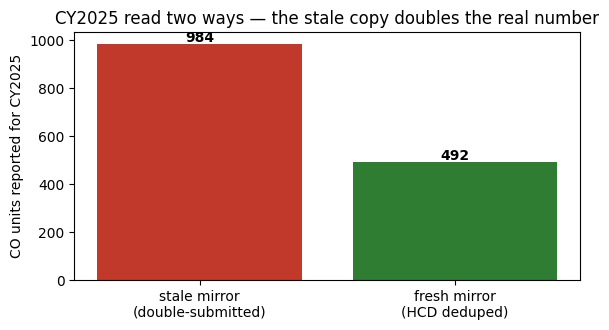

In [11]:
import matplotlib.pyplot as plt
# a two-bar comparison of the SAME year read from two copies of the oracle
_labels = ['stale mirror\n(double-submitted)', 'fresh mirror\n(HCD deduped)']
_vals = [stale[2025], fresh[2025]]
fig, ax = plt.subplots(figsize=(6, 3.4))
bars = ax.bar(_labels, _vals, color=['#c0392b', '#2e7d32'])
for b, v in zip(bars, _vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 8, str(v), ha='center', fontsize=10, fontweight='bold')
ax.set_title('CY2025 read two ways — the stale copy doubles the real number')
ax.set_ylabel('CO units reported for CY2025')
plt.tight_layout(); plt.show()

### Checkpoint 6a

In [12]:
assert fresh[2024] == 708, fresh[2024]
assert fresh[2025] == 492 and stale[2025] == 984
print('CHECKPOINT 6a PASS')
print(f'  oracle verified: CY2024 = 708 units (reconciles to anchor)')
print(f'  currency verified: CY2025 fresh = 492 (deduped) vs stale = 984 (the caught double-submission)')

CHECKPOINT 6a PASS
  oracle verified: CY2024 = 708 units (reconciles to anchor)
  currency verified: CY2025 fresh = 492 (deduped) vs stale = 984 (the caught double-submission)


# PHASE 6b — Generate your APR in HCD's form

Now the question flips: *forget the city's answer key — what does **your** reconstruction say?* You'll render your own completions (the ones you rebuilt from raw permits in JN1–JN5) into HCD's **Table A2** shape: completion **units by reporting year**, with the income-tier breakdown **where you actually have it**.

And here's the honest part — you *don't* have the tiers. The permit feed carries almost no affordability data, so those cells stay **explicitly blank and flagged**, never guessed. That's the honest-partial principle: **the spreadsheet is a rendering of your data, and the blanks are themselves a finding** (affordability is largely invisible in the built-permit record), not a hole to paper over.

**Our plan:** replay the JN1–JN5 reconstruction — load permits, keep housing, collapse to buildings by address key, find each building's finaled date — then total the completion units per reporting year. That per-year total is your APR's spine.

In [13]:
import pandas as pd
from collections import defaultdict
from housing_predicates import is_housing, net_units
from s0_keys import normalize_address
from cpra_dedup import extract_master_permit
def pdate(x):
    d = pd.to_datetime(str(x), errors='coerce'); return d.date() if pd.notna(d) else None
def load(p):
    d = pd.read_excel(p, dtype=str, header=HEADER_ROW); d.columns = [str(c).strip() for c in d.columns]; return d
df = pd.concat([load(f) for f in glob.glob(PERMIT_GLOB)], ignore_index=True)
df = df[df['PermitNumber'].notna()].rename(columns={'Finaled Date':'FinaledDate'}).copy()
df['isnew'] = df['Work Type'].astype(str).str.strip() == 'New'
df = df[[is_housing(o,u,n,a) for o,u,n,a in zip(df['OccType'],df['UnitsAdded'],df['NumberUnits'],df['ADU'])]]
bld = defaultdict(lambda: {'units': 0.0, 'hasnew': False, 'final': []})
for r in df.itertuples(index=False):
    st = r.StreetType; st = '' if (st is None or str(st).strip().lower() == 'nan') else str(st)
    k = normalize_address(f'{r.StreetNumber} {r.StreetName} {st}'.strip())
    if not k.number: continue
    b = bld[(k.number, k.street, k.stype)]
    b['units'] = max(b['units'], net_units(r.isnew, r.UnitsAdded, r.NumberUnits, r.ADU))
    if r.isnew: b['hasnew'] = True
    pn = str(r.PermitNumber)
    if extract_master_permit(pn) == pn and net_units(r.isnew, r.UnitsAdded, r.NumberUnits, r.ADU) > 0:
        f = pdate(r.FinaledDate)
        if f: b['final'].append(f)
completions = {k: b for k, b in bld.items() if (b['hasnew'] or b['units'] > 0) and b['final']}
my_units = defaultdict(int)
for b in completions.values(): my_units[max(b['final']).year] += int(b['units'])
print('MY APR - completion units by reporting_year:', dict(sorted(my_units.items())), 'sum', sum(my_units.values()))

MY APR - completion units by reporting_year: {2018: 228, 2019: 309, 2020: 398, 2021: 368, 2022: 679, 2023: 845, 2024: 783, 2025: 700} sum 4310


In [14]:
md(f'''## What just happened

Replaying the full JN1–JN5 chain — load, keep-housing, collapse-to-buildings, find finaled dates — your reconstruction totals **{sum(my_units.values()):,}** completion units across 2018–2025, built *entirely* from raw permits with no peeking at the oracle. Your CY2024 lands at **{my_units[2024]}** units (the oracle said **{fresh[2024]}** for the same year) and CY2025 at **{my_units[2025]}**. They're close but not identical — and that gap is the whole point of JN6b, where you'll decompose *why* your honest reconstruction and the city's filing disagree. For now, you have a defensible per-year number of your own.''')

## What just happened

Replaying the full JN1–JN5 chain — load, keep-housing, collapse-to-buildings, find finaled dates — your reconstruction totals **4,310** completion units across 2018–2025, built *entirely* from raw permits with no peeking at the oracle. Your CY2024 lands at **783** units (the oracle said **708** for the same year) and CY2025 at **700**. They're close but not identical — and that gap is the whole point of JN6b, where you'll decompose *why* your honest reconstruction and the city's filing disagree. For now, you have a defensible per-year number of your own.

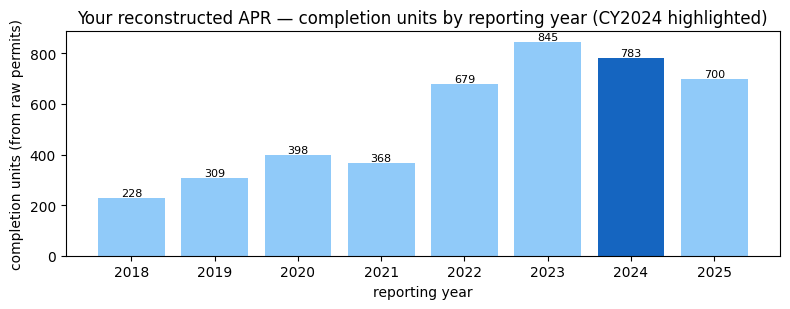

In [15]:
import matplotlib.pyplot as plt
# YOUR reconstructed APR: completion units by reporting year (read straight from my_units)
_yrs = sorted(my_units)
_vals = [my_units[y] for y in _yrs]
_colors = ['#1565c0' if y == 2024 else '#90caf9' for y in _yrs]
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar([str(y) for y in _yrs], _vals, color=_colors)
for y, v in zip(_yrs, _vals):
    ax.text(str(y), v + 8, str(v), ha='center', fontsize=8)
ax.set_title('Your reconstructed APR — completion units by reporting year (CY2024 highlighted)')
ax.set_xlabel('reporting year'); ax.set_ylabel('completion units (from raw permits)')
plt.tight_layout(); plt.show()

### Render the Table A2 shape — honest-partial

How do you write a real HCD form when you genuinely don't know one of its columns? You write what you know and you *flag* what you don't — you never invent a plausible-looking number to fill a blank. We know the total completion units per year (we just computed them, and they're sourced). We don't know the affordability tier split (VLI/LI/MOD/…), because the permit feed doesn't carry it.

**Our plan:** assemble the Table A2 rows with the real per-year totals, mark every tier cell `UNKNOWN` with a note explaining *why*, and save it to an `.xlsx` — a rendering of your reconstructed data, blanks and all.

In [16]:
import openpyxl
rows = []
for y in range(2018, 2026):
    rows.append({'YEAR': y, 'CO_TOTAL_UNITS': my_units[y],
                 'CO_VLOW': 'UNKNOWN', 'CO_LOW': 'UNKNOWN', 'CO_MOD': 'UNKNOWN',
                 'CO_ABOVE_MOD': 'UNKNOWN', 'NOTE': 'tier split not in permit feed (transparency gap)'})
table_a2 = pd.DataFrame(rows)
out_path = OUTDIR / 'my_apr_table_a2.xlsx'
table_a2.to_excel(out_path, index=False, sheet_name='Table A2 (completions)')
print('wrote', out_path)
table_a2[['YEAR','CO_TOTAL_UNITS','CO_VLOW','CO_ABOVE_MOD','NOTE']]

wrote /Users/johngage/berkeley-data/notebooks/curriculum/output/my_apr_table_a2.xlsx


,YEAR,CO_TOTAL_UNITS,CO_VLOW,CO_ABOVE_MOD,NOTE
0,2018,228,UNKNOWN,UNKNOWN,tier split not in permit feed (transparency gap)
1,2019,309,UNKNOWN,UNKNOWN,tier split not in permit feed (transparency gap)
2,2020,398,UNKNOWN,UNKNOWN,tier split not in permit feed (transparency gap)
3,2021,368,UNKNOWN,UNKNOWN,tier split not in permit feed (transparency gap)
4,2022,679,UNKNOWN,UNKNOWN,tier split not in permit feed (transparency gap)
5,2023,845,UNKNOWN,UNKNOWN,tier split not in permit feed (transparency gap)
6,2024,783,UNKNOWN,UNKNOWN,tier split not in permit feed (transparency gap)
7,2025,700,UNKNOWN,UNKNOWN,tier split not in permit feed (transparency gap)


In [17]:
_n_unknown = int((table_a2['CO_VLOW'] == 'UNKNOWN').sum())
md(f'''## What just happened

We wrote a real HCD-form Table A2 to `{out_path.name}` — **{len(table_a2)}** reporting years, totaling **{int(table_a2['CO_TOTAL_UNITS'].sum()):,}** completion units, with CY2024 at **{int(table_a2.loc[table_a2['YEAR']==2024,'CO_TOTAL_UNITS'].iloc[0])}**. And in all **{_n_unknown}** rows, every affordability tier reads `UNKNOWN`, each carrying a note that the split isn't in the permit feed. That isn't a half-finished form — it's an *honest* one. The blank tiers are a documented finding about the source data, and a reader can tell at a glance exactly which numbers are sourced and which are genuinely unavailable.''')

## What just happened

We wrote a real HCD-form Table A2 to `my_apr_table_a2.xlsx` — **8** reporting years, totaling **4,310** completion units, with CY2024 at **783**. And in all **8** rows, every affordability tier reads `UNKNOWN`, each carrying a note that the split isn't in the permit feed. That isn't a half-finished form — it's an *honest* one. The blank tiers are a documented finding about the source data, and a reader can tell at a glance exactly which numbers are sourced and which are genuinely unavailable.

### Checkpoint 6b

In [18]:
# NOTE - these literals are pinned to the FROZEN curriculum data bundle (the exact snapshot the
# Colab bootstrap fetches), so the checkpoint reproduces for every student. Point the course at
# fresher data and they will legitimately move - that is the data changing, not your code breaking.
assert sum(my_units.values()) == 4310            # the units the JN-chain reconstructed, on the frozen bundle
assert my_units[2024] == 783
assert (OUTDIR / 'my_apr_table_a2.xlsx').exists()
assert (table_a2['CO_VLOW'] == 'UNKNOWN').all()  # tiers honestly flagged, never fabricated
print('CHECKPOINT 6b PASS')
print(f'  my APR rendered: {sum(my_units.values())} total completion units (CY2024 = {my_units[2024]})')
print('  HCD-form xlsx written; affordability tiers explicitly flagged UNKNOWN (honest blanks)')

CHECKPOINT 6b PASS
  my APR rendered: 4310 total completion units (CY2024 = 783)
  HCD-form xlsx written; affordability tiers explicitly flagged UNKNOWN (honest blanks)


**JN6a done.** You have a verified oracle and your own HCD-form APR. **Next - JN6b:** join the two, decompose the difference, and let your own scorecard rediscover the limitation you planted in JN3.

<!-- NAV:auto-generated by scripts/build_nav.py — do not edit by hand -->

← Previous: [JN5 · Year & cycle tagging](https://colab.research.google.com/github/blockXblock/berkeley-housing-analysis/blob/main/notebooks/curriculum/JN5_year_cycle.ipynb)  |  Next: [JN6b · Join, decompose, score](https://colab.research.google.com/github/blockXblock/berkeley-housing-analysis/blob/main/notebooks/curriculum/JN6b_join_score.ipynb) →